In [1]:
from keras.datasets.cifar10 import load_data
# 引入cifar10資料集
((x_train, y_train), (x_test, y_test)) = load_data()

170498071/170498071 [==============================] - 3s 0us/step


In [2]:
print("訓練資料:", x_train.shape)
print("測試資料:", x_test.shape)

訓練資料: (50000, 32, 32, 3)
測試資料: (10000, 32, 32, 3)


In [3]:
trans = {0:"飛機", 1:"汽車", 2:"鳥", 3:"貓", 4:"鹿", 5:"狗", 6:"青蛙", 7:"馬", 8:"船", 9:"卡車"}

是什麼? 狗


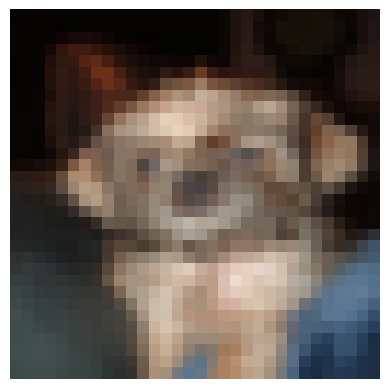

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline
import random
c = random.randint(0, 49999)
print("是什麼?", trans[y_train[c][0]])
plt.axis("off")
plt.imshow(x_train[c])

In [5]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Conv2D, MaxPooling2D
# 引入卷機, 磁化
from keras.layers import Flatten
cnn = Sequential()
cnn.add(Conv2D(32, (3, 3), padding="same", activation="relu", input_shape=(32, 32, 3)))
# 簡化VGG-16卷機神經網路
cnn.add(MaxPooling2D(pool_size=(2, 2)))
# 磁化
cnn.add(Conv2D(64, (3, 3), padding="same", activation="relu"))
cnn.add(MaxPooling2D(pool_size=(2, 2)))
cnn.add(Flatten())
# 圖片維度展平
cnn.add(Dense(256, activation="relu"))
# 中間神經設定activation="relu", 避免梯度下降
cnn.add(Dense(10, activation="softmax"))
# 一個輸出神經設定activation="sigmoid", 否則設定activation="softmax"
cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 8, 8, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 4096)              0         
                                                                 
 dense (Dense)               (None, 256)               1

In [6]:
cnn.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
# 一個輸出神經設定loss="binary_crossentropy", 否則設定loss="categorical_crossentropy"

In [7]:
x_train_norm = x_train / 255
x_test_norm = x_test / 255

In [8]:
from keras.utils import to_categorical
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)
print("Demo:", y_train_cat[0])

Demo: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [9]:
cnn.fit(x_train_norm, y_train_cat, batch_size=200, epochs=10, validation_split=0.1, verbose=2)
# epochs意思是模型訓練幾次

Epoch 1/10
225/225 - 81s - loss: 1.5723 - accuracy: 0.4343 - val_loss: 1.2732 - val_accuracy: 0.5490 - 81s/epoch - 362ms/step
Epoch 2/10
225/225 - 68s - loss: 1.2077 - accuracy: 0.5736 - val_loss: 1.1038 - val_accuracy: 0.6176 - 68s/epoch - 301ms/step
Epoch 3/10
225/225 - 68s - loss: 1.0534 - accuracy: 0.6324 - val_loss: 1.0315 - val_accuracy: 0.6438 - 68s/epoch - 303ms/step
Epoch 4/10
225/225 - 68s - loss: 0.9517 - accuracy: 0.6679 - val_loss: 0.9536 - val_accuracy: 0.6730 - 68s/epoch - 303ms/step
Epoch 5/10
225/225 - 69s - loss: 0.8722 - accuracy: 0.6975 - val_loss: 0.9208 - val_accuracy: 0.6818 - 69s/epoch - 306ms/step
Epoch 6/10
225/225 - 68s - loss: 0.8082 - accuracy: 0.7178 - val_loss: 0.8849 - val_accuracy: 0.7012 - 68s/epoch - 304ms/step
Epoch 7/10
225/225 - 67s - loss: 0.7498 - accuracy: 0.7402 - val_loss: 0.9018 - val_accuracy: 0.6928 - 67s/epoch - 300ms/step
Epoch 8/10
225/225 - 68s - loss: 0.6873 - accuracy: 0.7614 - val_loss: 0.9068 - val_accuracy: 0.6892 - 68s/epoch - 304

In [10]:
cnn.save("cifar10.h5")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [11]:
from keras.models import load_model
loaded = load_model("cifar10.h5")

In [12]:
loaded.evaluate(x_test_norm, y_test_cat)

313/313 [==============================] - 5s 15ms/step - loss: 0.8976 - accuracy: 0.6946


[0.8975764513015747, 0.694599986076355]